### Получаем данные

In [1]:
from src.mlcore.dataloader import get_processed_data

raw = get_processed_data(
    source="raw",
    symbol="BTCUSDC",
    drop_last=True,
    save_dir="parquets/",
    grid_resolution_ms=5000,
)
raw

orderbook_snapshots: 100%|██████████| 17/17 [00:14<00:00,  1.20it/s]


,exchange_ts,open,high,low,close,volume,volume_1s,buy_volume_1s,sell_volume_1s,volume_imbalance_1s,...,ask_qty_90,ask_qty_91,ask_qty_92,ask_qty_93,ask_qty_94,ask_qty_95,ask_qty_96,ask_qty_97,ask_qty_98,ask_qty_99
0,2026-01-23 11:50:30,89130.601562,89139.500000,89130.500000,89135.101562,0.769,0.000,0.000,0.000,0.000000,...,0.014,1.000,0.139,0.002,0.005,0.141,1.796,0.821,0.006,0.139
1,2026-01-23 11:50:35,89130.398438,89130.398438,89130.398438,89130.398438,0.002,0.196,0.000,0.196,-1.000000,...,0.139,0.002,0.139,0.744,0.139,1.010,1.796,0.139,0.112,1.139
2,2026-01-23 11:50:40,89130.398438,89130.398438,89130.398438,89130.398438,0.002,0.000,0.000,0.000,0.000000,...,0.020,0.023,0.139,1.094,0.139,1.075,1.796,0.139,1.008,1.139
3,2026-01-23 11:50:45,89130.398438,89130.398438,89128.000000,89128.101562,0.232,0.000,0.000,0.000,0.000000,...,0.002,0.139,1.094,0.139,1.122,1.796,0.139,1.011,0.112,1.307
4,2026-01-23 11:50:50,89128.101562,89128.101562,89128.101562,89128.101562,0.002,0.004,0.000,0.004,-1.000000,...,0.005,0.139,0.415,0.003,0.139,0.004,0.139,0.978,0.139,0.744
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
687709,2026-03-04 06:59:35,68465.101562,68465.101562,68465.101562,68465.101562,0.231,0.161,0.000,0.161,-1.000000,...,0.010,0.002,0.417,0.881,0.278,0.700,0.013,0.008,0.004,0.002
687710,2026-03-04 06:59:40,68475.500000,68476.203125,68469.398438,68472.796875,0.581,0.227,0.227,0.000,1.000000,...,0.002,0.211,0.057,0.316,0.175,0.004,0.004,0.003,0.656,0.004
687711,2026-03-04 06:59:45,68483.000000,68486.203125,68471.000000,68485.601562,3.558,3.485,1.585,1.900,-0.090387,...,0.040,0.002,0.002,0.002,0.031,0.038,0.881,0.315,0.656,0.236
687712,2026-03-04 06:59:50,68469.398438,68469.398438,68469.398438,68469.398438,0.012,0.000,0.000,0.000,0.000000,...,0.011,0.003,0.002,0.100,0.056,0.035,0.004,0.984,0.632,0.029


### Определяем таргеты для всех моделей

In [2]:
import numpy as np
import pandas as pd
from tqdm import tqdm


def calculate_mid_target(df: pd.DataFrame):
    target = np.zeros(len(df), dtype=float)
    for i in tqdm(range(len(df) - 1)):
        current = df['close'].iloc[i]
        mid = (df['high'].iloc[i+1] + df['low'].iloc[i+1]) / 2.0
        target[i] = np.log(mid / current)
    return pd.Series(target, index=df.index)


def calculate_spread_target(df: pd.DataFrame):
    target = np.zeros(len(df), dtype=float)
    for i in tqdm(range(len(df) - 1)):
        current = df['close'].iloc[i]
        spread = df['high'].iloc[i+1] - df['low'].iloc[i+1]
        target[i] = spread / current
    return pd.Series(target, index=df.index)


mid_target = calculate_mid_target(raw)
spread_target = calculate_spread_target(raw)

100%|██████████| 687713/687713 [00:06<00:00, 110432.45it/s]


### Генерируем фичи для всех моделей

In [3]:
from src.mlcore.dataloader import calculate_features

df = calculate_features(raw, filename='all_features')
df['low'] = raw['low']
df['high'] = raw['high']
df['close'] = raw['close']
df['mid_target'] = mid_target
df['spread_target'] = spread_target
df.dropna(inplace=True)
df

,adverse_selection_risk,ask_price_pressure,atr,atr_exponential_smoothing_alpha_0_8,bid_ask_cancellation_proxy5,bid_ask_spread_tightness_index,bid_price_pressure,combo16_weighted_orderbook_log_times_slope,combo29_response_imbalance_log1p_times_wli,combo35_fqi_rolling_std_18_times_slope,...,volatility_contraction_expansion_ratio,weighted_depth_ratio,weighted_log_imbalance_5levels,weighted_orderbook_imbalance,weighted_price_pressure,low,high,close,mid_target,spread_target
30,1.720052,4.470000,4.350781,4.826048,0.000159,1.720241,0.399000,-0.282542,-0.043540,-3.870383,...,0.137217,0.862152,-0.825813,-0.537971,-0.540668,89142.398438,89150.796875,89145.703125,0.000001,0.000000
31,1.673307,0.248484,4.208880,4.584924,0.000214,1.673463,0.588047,3.569189,0.434759,32.839458,...,0.130333,4.493296,4.811982,0.943113,0.945398,89145.796875,89145.796875,89145.796875,0.000000,0.000000
32,1.826563,0.965219,4.068584,4.278148,0.000275,1.826706,0.176813,2.594957,0.397548,28.002368,...,0.130333,3.452995,3.723537,0.751790,0.752639,89145.796875,89145.796875,89145.796875,0.000000,0.000000
33,1.826563,0.026508,3.932965,3.976710,0.000443,1.826679,0.055969,0.989410,0.123907,17.214146,...,0.126951,2.117040,2.170741,0.394916,0.393676,89145.796875,89145.796875,89145.796875,0.000051,0.000001
34,1.788281,0.026914,3.955251,3.956434,0.000956,1.788374,0.056250,0.976829,0.122001,16.139879,...,0.133917,2.066252,2.160544,0.390597,0.389091,89150.296875,89150.398438,89150.398438,0.000020,0.000039
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
687709,5.700521,0.716953,10.918343,9.660698,0.000017,5.700513,0.579000,-0.068336,-0.012760,-3.348395,...,0.306956,0.412384,-0.121821,0.168921,0.178742,68465.101562,68465.101562,68465.101562,0.000112,0.000099
687710,5.636979,0.171367,10.924450,9.655979,0.000007,5.636971,0.210000,0.806854,0.219636,26.756902,...,0.320248,1.266121,2.637432,0.245033,0.142583,68469.398438,68476.203125,68472.796875,0.000085,0.000222
687711,5.830339,0.189258,11.067072,9.972083,0.000002,5.830315,0.009000,-2.100421,-1.164579,-30.760937,...,0.327739,0.606502,-3.246863,-0.660488,-0.672605,68471.000000,68486.203125,68485.601562,-0.000237,0.000000
687712,5.900260,0.120922,11.238274,10.386847,0.000007,5.900237,0.036133,-0.427476,-0.155905,-10.340481,...,0.352858,0.228924,-0.658385,0.369318,0.442198,68469.398438,68469.398438,68469.398438,0.000000,0.000000


In [4]:
feature_columns = [col for col in df.columns if col not in ['mid_target', 'spread_target', 'close', 'high', 'low']]
X = df[feature_columns].copy()
y_mid = df['mid_target'].copy()
y_spread = df['spread_target'].copy()
ohlcv = df[['close', 'high', 'low']].copy()

split_index = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_mid_train, y_mid_test = y_mid.iloc[:split_index], y_mid.iloc[split_index:]
y_spread_train, y_spread_test = y_spread.iloc[:split_index], y_spread.iloc[split_index:]
_, ohlcv_test = ohlcv.iloc[:split_index], ohlcv.iloc[split_index:]

### Обучаем mid model

In [5]:
from src.mlcore.train import train_regression_model

mid_model = train_regression_model(
    X_train=X_train,
    y_train=y_mid_train,
    X_test=X_test,
    y_test=y_mid_test,
    n_estimators=5000,
    objective='reg:squarederror',
    model_name="model_mid",
    max_depth=3,
)

Обучение модели...
[0]	validation_0-rmse:0.00023
[50]	validation_0-rmse:0.00022
[100]	validation_0-rmse:0.00022
[150]	validation_0-rmse:0.00021
[200]	validation_0-rmse:0.00021
[250]	validation_0-rmse:0.00021
[300]	validation_0-rmse:0.00021
[350]	validation_0-rmse:0.00021
[400]	validation_0-rmse:0.00021
[450]	validation_0-rmse:0.00021
[500]	validation_0-rmse:0.00021
[550]	validation_0-rmse:0.00021
[600]	validation_0-rmse:0.00021
[650]	validation_0-rmse:0.00021
[700]	validation_0-rmse:0.00021
[750]	validation_0-rmse:0.00021
[800]	validation_0-rmse:0.00021
[850]	validation_0-rmse:0.00021
[900]	validation_0-rmse:0.00021
[950]	validation_0-rmse:0.00021
[1000]	validation_0-rmse:0.00021
[1050]	validation_0-rmse:0.00021
[1100]	validation_0-rmse:0.00021
[1150]	validation_0-rmse:0.00021
[1200]	validation_0-rmse:0.00021
[1250]	validation_0-rmse:0.00021
[1300]	validation_0-rmse:0.00021
[1350]	validation_0-rmse:0.00021
[1400]	validation_0-rmse:0.00021
[1450]	validation_0-rmse:0.00021
[1500]	validat

MAE                      : 0.000130
RMSE                     : 0.000206
R²                       : 0.204697
MAE / mean|Δ|            : 0.857580
RMSE / RMSE_base         : 0.891792
mean|Δ| (target)         : 0.000152

------------------------------------------------------------
Directional Accuracy     : 0.636760
Target Pos Ratio         : 0.489810
Profit Factor            : 1.614971
Avg Gain (correct)       : -0.000003
Avg Loss (incorrect)     : 0.000004

------------------------------------------------------------
Binomial p-value (vs 50%)     : 0.000000
Directional Acc 95% CI        : (0.6342, 0.6391)
Is Significant (α=5%)         : True

📊 Квантильный анализ (топ-3 квантиля по уверенности):
            quantile  confidence  directional_acc  mean_return  n_samples
 (0.000124, 0.00138]    0.000223         0.904246    -0.000001      13754
(7.09e-05, 0.000124]    0.000093         0.786171    -0.000001      13754
(4.88e-05, 7.09e-05]    0.000059         0.703774     0.000003      13753


/Users/honeysuckle/dev/AlgoTradingSystem_c1/src/mlcore/evaluation.py:130: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for q, group in df.groupby('quantile'):


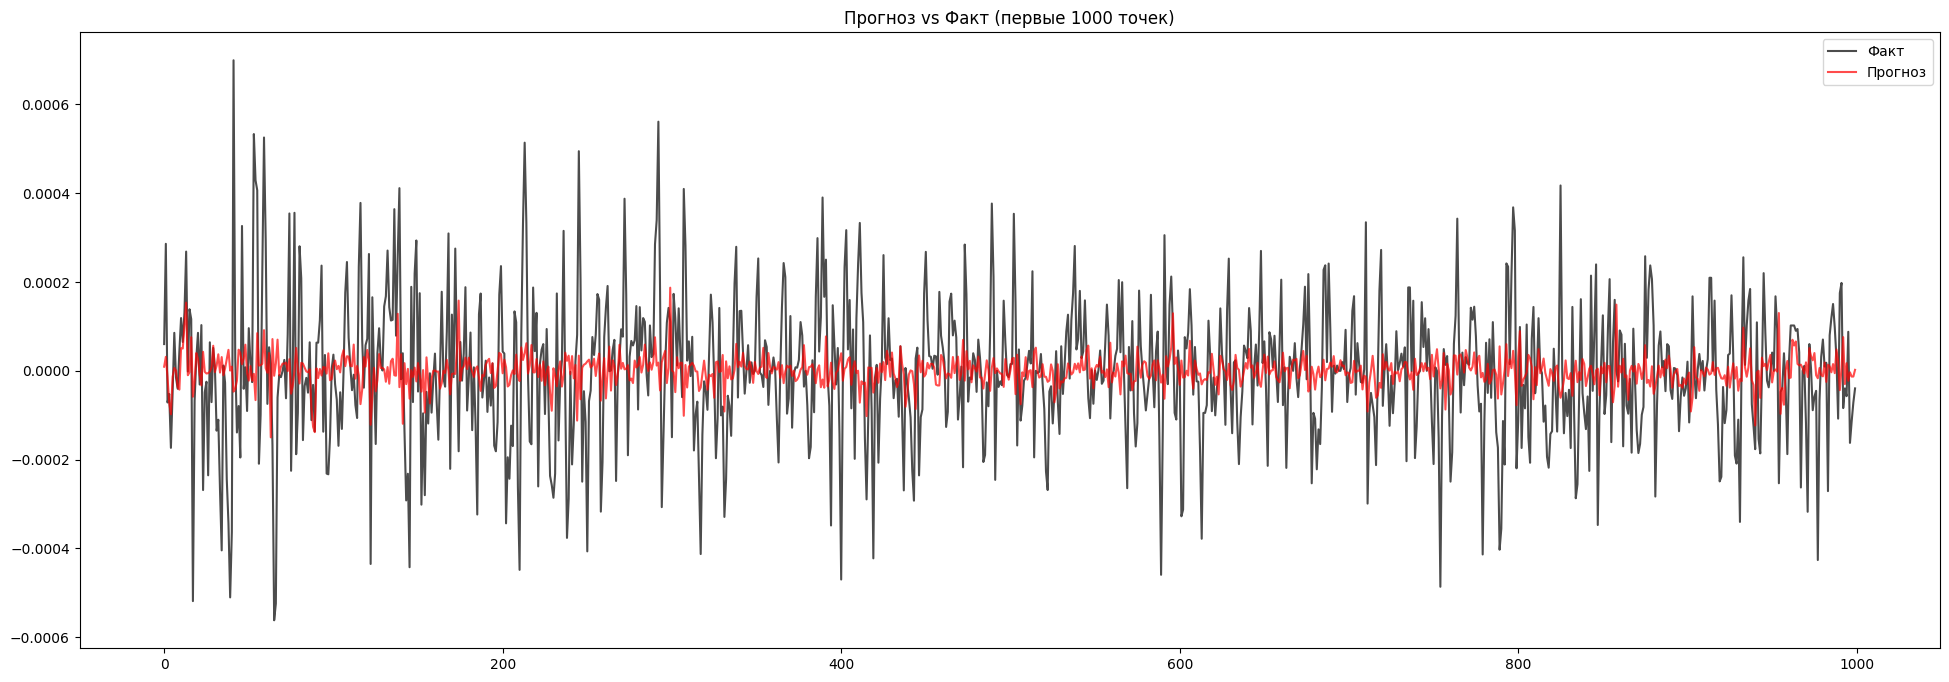

In [6]:
from src.mlcore.evaluation import evaluate_regression_model

y_mid_pred = mid_model.predict(X_test)

evaluate_regression_model(
    y_test=y_mid_test,
    y_pred=y_mid_pred,
    length=1000,
)

### Обучаем spread model

In [7]:
from src.mlcore.train import train_regression_model

spread_model = train_regression_model(
    X_train=X_train,
    y_train=y_spread_train,
    X_test=X_test,
    y_test=y_spread_test,
    n_estimators=5000,
    objective='reg:squaredlogerror',
    model_name="model_spread",
    max_depth=6,
)

Обучение модели...
[0]	validation_0-rmse:0.00024
[50]	validation_0-rmse:0.00021
[100]	validation_0-rmse:0.00019
[150]	validation_0-rmse:0.00019
[200]	validation_0-rmse:0.00019
[250]	validation_0-rmse:0.00019
[300]	validation_0-rmse:0.00019
[350]	validation_0-rmse:0.00019
[400]	validation_0-rmse:0.00019
[450]	validation_0-rmse:0.00019
[500]	validation_0-rmse:0.00019
[550]	validation_0-rmse:0.00019
[562]	validation_0-rmse:0.00019
Модель сохранена в директорию: models/model_spread.json


MAE                      : 0.000122
RMSE                     : 0.000187
R²                       : 0.395751
MAE / mean|Δ|            : 0.523398
RMSE / RMSE_base         : 0.558153
mean|Δ| (target)         : 0.000233

------------------------------------------------------------
Directional Accuracy     : 0.945069
Target Pos Ratio         : 0.945069
Profit Factor            : 32102178829.760944
Avg Gain (correct)       : 0.000247
Avg Loss (incorrect)     : 0.000000

------------------------------------------------------------
Binomial p-value (vs 50%)     : 0.000000
Directional Acc 95% CI        : (0.9438, 0.9462)
Is Significant (α=5%)         : True

📊 Квантильный анализ (топ-3 квантиля по уверенности):
            quantile  confidence  directional_acc  mean_return  n_samples
 (0.000417, 0.00281]    0.000592         1.000000     0.000583      13754
(0.000308, 0.000417]    0.000355         0.998691     0.000350      13754
(0.000256, 0.000308]    0.000281         0.994837     0.000280    

/Users/honeysuckle/dev/AlgoTradingSystem_c1/src/mlcore/evaluation.py:130: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for q, group in df.groupby('quantile'):


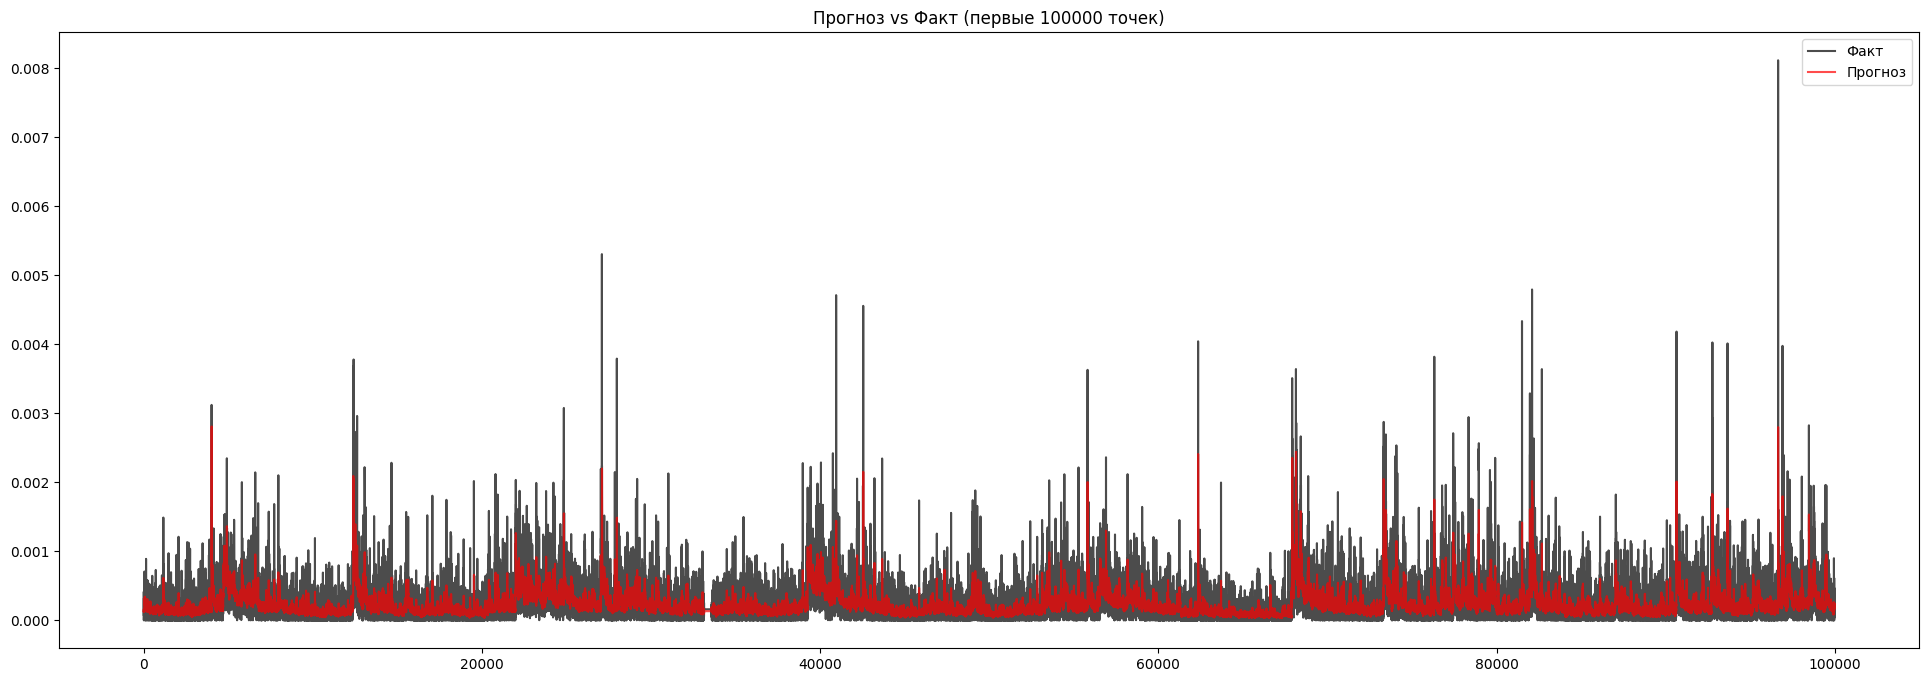

In [8]:
from src.mlcore.evaluation import evaluate_regression_model

y_spread_pred = spread_model.predict(X_test)

evaluate_regression_model(
    y_test=y_spread_test,
    y_pred=y_spread_pred,
    length=100000,
)